Link Google Colab: https://colab.research.google.com/drive/1ng1sGZHCbPBCwahF5hnKbIH6DQ9QgFtf?usp=sharing

# model indobert untuk deteksi spoiler review buku goodreads

input  -> `review_preprocessed.csv`
kolom  -> `review_text_clean`, `spoiler_label`
model  -> `indobenchmark/indobert-base-p2`

alur notebook:
load data -> split data -> tokenisasi bert -> setup dataset pytorch ->
definisi weighted trainer -> training dengan early stopping ->
threshold tuning di val set -> evaluasi final di test set -> visualisasi paper

catatan: indobert dipilih karena di-pretrain khusus pada korpus bahasa indonesia
(wikipedia, berita, web crawl), lebih dalam menangkap nuansa bahasa indonesia
dibanding model multilingual seperti xlm-roberta atau mbert.

## 1. verifikasi gpu

indobert cukup besar untuk fine-tuning. tanpa gpu proses ini bisa memakan berjam-jam.
pastikan runtime sudah diganti ke gpu t4 di google colab sebelum menjalankan notebook ini.

In [ ]:
# cek apakah GPU tersedia dan modelnya apa
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
  print("GPU tersedia!")
  # tampilkan baris pertama saja yang berisi nama GPU
  for line in result.stdout.split("\n"):
    if "Tesla" in line or "T4" in line or "A100" in line or "V100" in line:
      print(line)
      break
else:
  print("GPU tidak terdeteksi!")

GPU tersedia!
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


## 2. instalasi dan import library

In [ ]:
# transformers: library utama dari HuggingFace yang berisi model BERT dan Trainer
# datasets: format data yang digunakan oleh HuggingFace Trainer
# accelerate: diperlukan oleh Trainer untuk manajemen GPU
!pip install -q transformers datasets accelerate

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch

from transformers import (
  AutoTokenizer,
  AutoModelForSequenceClassification,
  TrainingArguments,
  Trainer,
  EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  classification_report,
  confusion_matrix,
  roc_auc_score,
  roc_curve,
  f1_score,
  precision_score,
  recall_score,
  ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# konfigurasi utama
MODEL_NAME = "indobenchmark/indobert-base-p2"  # model yang akan di-fine-tune
RANDOM_SEED = 42
MAX_LEN = 256         # panjang token maksimum per input
BATCH_SIZE = 16       # jumlah sampel per batch saat training
MAX_EPOCHS = 10       # EarlyStoppingCallback akan berhenti lebih awal jika tidak ada perbaikan
LEARNING_RATE = 5e-6  # learning rate kecil karena kita fine-tuning, bukan training dari nol

# set seed untuk reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch versi: {torch.__version__}")
print(f"GPU tersedia: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
  print(f"Memory GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch versi: 2.11.0+cu128
GPU tersedia: True
Nama GPU: Tesla T4
Memory GPU: 15.6 GB


## 3. mount google drive dan load data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# sesuaikan path ini dengan lokasi file di Google Drive kamu
DRIVE_BASE = "/content/drive/MyDrive/NLP_Kelompok3"
INPUT_CSV = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
OUTPUT_DIR = os.path.join(DRIVE_BASE, "indobert_output")  # folder untuk simpan checkpoint

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"path dataset: {INPUT_CSV}")
print(f"output dir: {OUTPUT_DIR}")

Mounted at /content/drive
path dataset: /content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv
output dir: /content/drive/MyDrive/NLP_Kelompok3/indobert_output


In [ ]:
# load dataset
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris: {len(df)}")
print(f"kolom: {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\nmissing values")
print(df[["review_text_clean", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
df = df.dropna(subset=["review_text_clean", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah hapus missing: {len(df)} baris")

total baris: 11267
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values
review_text_clean    0
spoiler_label        0
dtype: int64

setelah hapus missing: 11267 baris


In [ ]:
# cek distribusi label dan hitung imbalance ratio
label_counts = df["spoiler_label"].value_counts()
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler

print("distribusi label")
print(pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : (label_counts / len(df) * 100).round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"}))

print(f"\nimbalance ratio: {imbalance_ratio:.2f}")

# siapkan data X dan y
texts = df["review_text_clean"].astype(str).tolist()
labels = df["spoiler_label"].astype(int).tolist()

distribusi label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)   10281   91.25
spoiler (1)         986    8.75

imbalance ratio: 10.43


## 4. tokenisasi dengan indobert tokenizer

bert tidak menerima teks mentah. teks harus dikonversi ke token integer menggunakan
wordpiece tokenizer bawaan bert. panjang maksimum 256 token per input.

token khusus yang ditambahkan otomatis:
- [cls] di awal -> representasi seluruh kalimat, dipakai untuk klasifikasi
- [sep] di akhir -> penanda akhir sequence
- [pad] -> padding untuk menyamakan panjang antar input dalam satu batch

In [ ]:
# load tokenizer IndoBERT dari HuggingFace
# pertama kali dijalankan akan download file ~500MB dari internet
print(f"loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\nukuran vocabulary tokenizer: {tokenizer.vocab_size:,} token")
print(f"token khusus: {tokenizer.all_special_tokens}")

loading tokenizer: indobenchmark/indobert-base-p2


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


ukuran vocabulary tokenizer: 30,521 token
token khusus: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [ ]:
# contoh tokenisasi untuk memahami cara kerja tokenizer
contoh = "ternyata si pembunuhnya adalah ayah dari tokoh utama sendiri"
tokens = tokenizer.tokenize(contoh)
ids = tokenizer.encode(contoh)

print(f"teks asli: {contoh}")
print(f"tokens: {tokens}")
print(f"token IDs: {ids}")
print(f"\nperhatikan: [CLS] ditambahkan di awal (ID={tokenizer.cls_token_id})")
print(f"dan [SEP] ditambahkan di akhir (ID={tokenizer.sep_token_id})")

teks asli: ternyata si pembunuhnya adalah ayah dari tokoh utama sendiri
tokens: ['ternyata', 'si', 'pembunuh', '##nya', 'adalah', 'ayah', 'dari', 'tokoh', 'utama', 'sendiri']
token IDs: [2, 1369, 356, 11767, 57, 154, 2161, 98, 2546, 1256, 536, 3]

perhatikan: [CLS] ditambahkan di awal (ID=2)
dan [SEP] ditambahkan di akhir (ID=3)


In [ ]:
# analisis distribusi panjang token pada data kita
# ini penting untuk memahami seberapa banyak teks yang terpotong oleh MAX_LEN=256
print("menghitung panjang token semua review (bisa beberapa menit)...")

token_lengths = []
for text in texts:
  tokens = tokenizer.encode(text, add_special_tokens=True)
  token_lengths.append(len(tokens))

print("\ndistribusi panjang token")
for p in [25, 50, 75, 90, 95, 99]:
  print(f"persentil {p:3d}: {np.percentile(token_lengths, p):.0f} token")
print(f"maksimum: {max(token_lengths)} token")

covered = sum(1 for l in token_lengths if l <= MAX_LEN)
print(f"\nreview yang masuk penuh (<= {MAX_LEN} token): {covered}/{len(texts)} ({covered/len(texts)*100:.1f}%)")
print(f"review yang terpotong: {len(texts)-covered}/{len(texts)} ({(len(texts)-covered)/len(texts)*100:.1f}%)")

menghitung panjang token semua review (bisa beberapa menit)...

distribusi panjang token
persentil  25: 41 token
persentil  50: 91 token
persentil  75: 192 token
persentil  90: 336 token
persentil  95: 436 token
persentil  99: 748 token
maksimum: 2582 token

review yang masuk penuh (<= 256 token): 9374/11267 (83.2%)
review yang terpotong: 1893/11267 (16.8%)


## 5. pembagian data: train, validation, test

tiga partisi sama seperti notebook bilstm:
- test set hanya disentuh sekali di evaluasi final
- threshold tuning dilakukan di validation set, bukan test set

In [ ]:
# langkah 1: pisahkan test set dulu (80% sisa + 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
  texts, labels,
  test_size=0.2,
  stratify=labels, # pastikan proporsi label sama
  random_state=RANDOM_SEED
)

# langkah 2: dari 80% sisanya, ambil 15% untuk validation
# hasil akhir: ~68% train, ~12% val, ~20% test
X_train, X_val, y_train, y_val = train_test_split(
  X_temp, y_temp,
  test_size=0.15,
  stratify=y_temp,
  random_state=RANDOM_SEED
)

print(f"train set: {len(X_train)} sampel")
print(f"val set: {len(X_val)} sampel")
print(f"test set: {len(X_test)} sampel")

# verifikasi proporsi label di setiap partisi
print("\nproporsi spoiler per partisi")
for nama, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
  ratio = sum(y) / len(y)
  print(f"  {nama:5s} : {sum(y)} spoiler dari {len(y)} ({ratio*100:.2f}%)")

# hitung class weight berdasarkan distribusi di train set
n_train_spoiler = sum(y_train)
n_train_nonspoiler = len(y_train) - n_train_spoiler
weight_nonspoiler = len(y_train) / (2 * n_train_nonspoiler)
weight_spoiler = len(y_train) / (2 * n_train_spoiler)

print(f"\nclass weight yang akan dipakai:")
print(f"non-spoiler (0): {weight_nonspoiler:.4f}")
print(f"spoiler (1): {weight_spoiler:.4f}")
print(f"artinya: kesalahan pada spoiler dihukum {weight_spoiler/weight_nonspoiler:.1f}x lebih berat")

train set: 7661 sampel
val set: 1352 sampel
test set: 2254 sampel

proporsi spoiler per partisi
  train : 671 spoiler dari 7661 (8.76%)
  val   : 118 spoiler dari 1352 (8.73%)
  test  : 197 spoiler dari 2254 (8.74%)

class weight yang akan dipakai:
non-spoiler (0): 0.5480
spoiler (1): 5.7086
artinya: kesalahan pada spoiler dihukum 10.4x lebih berat


## 6. membuat dataset object

huggingface trainer membutuhkan data dalam format torch.utils.data.dataset.
cell ini membuat wrapper kelas yang mengemas input_ids, attention_mask, dan label
ke format yang diharapkan trainer.

In [ ]:
class SpoilerDataset(Dataset):
  """
  dataset class untuk HuggingFace Trainer.
  menerima list teks dan label, mengembalikan tensor yang siap diproses BERT.
  """

  def __init__(self, texts, labels, tokenizer, max_len):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    # wajib ada: memberitahu Trainer berapa banyak sampel yang ada
    return len(self.texts)

  def __getitem__(self, idx):
    # wajib ada: dipanggil setiap kali Trainer minta satu sampel
    text  = str(self.texts[idx])
    label = int(self.labels[idx])

    # tokenisasi teks
    # truncation=True  : potong jika lebih dari max_len
    # padding='max_length': pad sampai tepat max_len
    # return_tensors='pt' : kembalikan sebagai PyTorch tensor
    encoding = self.tokenizer(
      text,
      max_length=self.max_len,
      padding="max_length",
      truncation=True,
      return_tensors="pt"
    )

    return {
      # squeeze() untuk menghilangkan dimensi batch yang tidak diperlukan
      "input_ids"      : encoding["input_ids"].squeeze(),
      "attention_mask" : encoding["attention_mask"].squeeze(),
      "labels"         : torch.tensor(label, dtype=torch.long)
    }

# buat dataset object untuk masing-masing partisi
train_dataset = SpoilerDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SpoilerDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SpoilerDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f"train dataset: {len(train_dataset)} sampel")
print(f"val dataset: {len(val_dataset)} sampel")
print(f"test dataset: {len(test_dataset)} sampel")

# cek satu sampel untuk memastikan format sudah benar
sampel = train_dataset[0]
print(f"\nbentuk input_ids: {sampel['input_ids'].shape}")
print(f"bentuk attention_mask: {sampel['attention_mask'].shape}")
print(f"label: {sampel['labels']}")

train dataset: 7661 sampel
val dataset: 1352 sampel
test dataset: 2254 sampel

bentuk input_ids: torch.Size([256])
bentuk attention_mask: torch.Size([256])
label: 0


## 7. load model dan definisi weighted trainer

fine-tuning: bobot pretrained indobert sudah sangat baik, kita hanya perlu
mengajarkan satu tugas spesifik baru (klasifikasi spoiler) dengan beberapa epoch saja.

weighted trainer: kelas khusus yang meng-override compute_loss bawaan trainer
untuk menerapkan class weight pada fungsi loss, menangani ketidakseimbangan kelas.

In [ ]:
# load model IndoBERT dengan classification head
# num_labels=2: dua kelas (non-spoiler dan spoiler)
# pertama kali dijalankan akan download bobot model ~500MB
print(f"loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
  MODEL_NAME,
  num_labels=2,
  # ignore_mismatched_sizes karena kita menambahkan classification head baru
  ignore_mismatched_sizes=True
)

# hitung total parameter model
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\ntotal parameter: {total_params:,}")
print(f"yang di-train: {trainable:,}")

loading model: indobenchmark/indobert-base-p2


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



total parameter: 124,442,882
yang di-train: 124,442,882


In [ ]:
class WeightedTrainer(Trainer):
  """
  subclass dari HuggingFace Trainer yang mengganti loss function standar
  dengan weighted cross entropy loss untuk menangani imbalanced class.

  cara kerjanya: setiap sampel spoiler (kelas 1) mendapat bobot lebih besar
  dalam perhitungan loss, sehingga model lebih fokus belajar dari spoiler
  yang jumlahnya sedikit.
  """

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    # ambil label dari batch
    labels = inputs.get("labels")

    # jalankan model untuk dapat prediksi
    outputs = model(**inputs)
    logits  = outputs.get("logits")

    # definisikan bobot per kelas
    # bobot dikirim ke device yang sama dengan logits (GPU atau CPU)
    class_weights = torch.tensor(
        [weight_nonspoiler, weight_spoiler],
        dtype=torch.float
    ).to(logits.device)

    # hitung weighted cross entropy loss
    loss_fn = CrossEntropyLoss(weight=class_weights)
    loss    = loss_fn(logits, labels)

    return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
  """
  fungsi untuk menghitung metrik evaluasi selama training.
  dipanggil di akhir setiap epoch oleh Trainer.
  """
  logits, labels = eval_pred
  # ambil kelas dengan skor tertinggi sebagai prediksi
  predictions = np.argmax(logits, axis=-1)
  # hitung probabilitas kelas spoiler menggunakan softmax
  probs_spoiler = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

  auc = roc_auc_score(labels, probs_spoiler)
  f1  = f1_score(labels, predictions, pos_label=1, zero_division=0)
  rec = recall_score(labels, predictions, pos_label=1, zero_division=0)

  return {
    "auc_roc"       : round(auc, 4),
    "f1_spoiler"    : round(f1, 4),
    "recall_spoiler": round(rec, 4)
  }

## 8. training

learning rate 5e-6 dipakai untuk fine-tuning (sangat kecil) supaya penyesuaian bobot
berlangsung halus dan tidak merusak representasi yang sudah dipelajari saat pretrain.

warmup steps: learning rate dinaikkan bertahap dari nol di beberapa langkah pertama
untuk stabilisasi awal training.

early stopping memantau auc-roc di validation set dengan patience 3 epoch.

In [ ]:
# hitung total training steps untuk konfigurasi warmup
steps_per_epoch = len(train_dataset) // BATCH_SIZE
warmup_steps = steps_per_epoch * 1  # warmup selama 1 epoch pertama
total_steps = steps_per_epoch * MAX_EPOCHS

print(f"sampel train: {len(train_dataset)}")
print(f"steps per epoch: {steps_per_epoch}")
print(f"warmup steps: {warmup_steps}")
print(f"total steps (maks): {total_steps}")

training_args = TrainingArguments(
  output_dir=OUTPUT_DIR,

  # konfigurasi training
  num_train_epochs=MAX_EPOCHS,
  per_device_train_batch_size=BATCH_SIZE,
  per_device_eval_batch_size=BATCH_SIZE,
  learning_rate=LEARNING_RATE,
  warmup_steps=warmup_steps,

  # weight decay: regularisasi tambahan untuk mencegah overfitting
  # bekerja dengan mengecilkan bobot model setiap step
  weight_decay=0.1,

  # konfigurasi evaluasi dan penyimpanan
  # eval_strategy='epoch' berarti evaluasi dilakukan di akhir setiap epoch
  eval_strategy="epoch",
  save_strategy="epoch",

  # pantau auc_roc untuk menentukan model terbaik dan early stopping
  metric_for_best_model="auc_roc",
  greater_is_better=True,
  load_best_model_at_end=True,   # setelah training selesai, muat bobot terbaik

  # simpan maksimal 2 checkpoint untuk hemat storage
  save_total_limit=2,

  logging_dir=os.path.join(OUTPUT_DIR, "logs"),
  logging_steps=steps_per_epoch,  # log setiap epoch

  # fp16=True menggunakan 16-bit floating point untuk mempercepat training di GPU
  fp16=torch.cuda.is_available(),

  seed=RANDOM_SEED,
  report_to="none" # matikan wandb/tensorboard logging
)

sampel train: 7661
steps per epoch: 478
warmup steps: 478
total steps (maks): 4780


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# inisialisasi trainer
trainer = WeightedTrainer(
  model=model,
  args=training_args,
  train_dataset=train_dataset,
  eval_dataset=val_dataset,
  compute_metrics=compute_metrics,
  callbacks=[
    # hentikan training jika AUC validasi tidak meningkat selama 3 epoch berturut-turut
    # restore_best_model=True memastikan bobot terbaik yang digunakan di akhir
    EarlyStoppingCallback(early_stopping_patience=2)
  ]
)

# mulai training
# estimasi waktu: 5-15 menit per epoch di GPU T4 tergantung panjang data
print("memulai training IndoBERT...")
print(f"maksimum {MAX_EPOCHS} epoch, bisa berhenti lebih awal (early stopping patience=3)")
print()

train_result = trainer.train()

print(f"\ntraining selesai!")
print(f"total waktu training: {train_result.metrics['train_runtime']:.1f} detik")
print(f"samples per second: {train_result.metrics['train_samples_per_second']:.1f}")

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

memulai training IndoBERT...
maksimum 10 epoch, bisa berhenti lebih awal (early stopping patience=3)



Epoch,Training Loss,Validation Loss,Auc Roc,F1 Spoiler,Recall Spoiler
1,0.666083,0.643342,0.701300,0.234300,0.788100
2,0.623378,0.598228,0.740300,0.288000,0.610200
3,0.549571,0.641466,0.754100,0.336500,0.449200
4,0.489265,0.743828,0.749700,0.277400,0.322000
5,0.396362,1.316920,0.739100,0.227300,0.169500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


training selesai!
total waktu training: 654.5 detik
samples per second: 117.0


In [ ]:
# cek detail training IndoBERT
print("RINGKASAN TRAINING INDOBERT")
print(f"AUC terbaik di val set: {trainer.state.best_metric:.4f}")
print(f"path checkpoint terbaik: {trainer.state.best_model_checkpoint}")
print()

print("log per epoch")
print(f"{'epoch':>6} {'eval_loss':>10} {'eval_auc':>10} {'eval_f1':>10} {'eval_rec':>10}")
print("-" * 50)
for log in trainer.state.log_history:
  if "eval_auc_roc" in log:
    marker = " <-- terbaik" if abs(log['eval_auc_roc'] - trainer.state.best_metric) < 0.0001 else ""
    print(f"{log['epoch']:>6.0f} {log['eval_loss']:>10.4f} {log['eval_auc_roc']:>10.4f} "
          f"{log.get('eval_f1_spoiler',0):>10.4f} "
          f"{log.get('eval_recall_spoiler',0):>10.4f}{marker}")

RINGKASAN TRAINING INDOBERT
AUC terbaik di val set: 0.7541
path checkpoint terbaik: /content/drive/MyDrive/NLP_Kelompok3/indobert_output/checkpoint-1437

log per epoch
 epoch  eval_loss   eval_auc    eval_f1   eval_rec
--------------------------------------------------
     1     0.6433     0.7013     0.2343     0.7881
     2     0.5982     0.7403     0.2880     0.6102
     3     0.6415     0.7541     0.3365     0.4492 <-- terbaik
     4     0.7438     0.7497     0.2774     0.3220
     5     1.3169     0.7391     0.2273     0.1695


## 9. threshold tuning dan evaluasi final

threshold optimal dicari di validation set, lalu diterapkan ke test set.
test set baru disentuh di sini setelah semua keputusan (termasuk threshold) sudah dibuat.

In [ ]:
# dapatkan prediksi probabilitas di validation set
print("menghitung prediksi di validation set...")
val_predictions = trainer.predict(val_dataset)
val_logits = val_predictions.predictions

# konversi logits ke probabilitas menggunakan softmax
# ambil kolom 1 (probabilitas kelas spoiler)
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1)[:, 1].numpy()
y_val_arr = np.array(y_val)

# hitung AUC di validation set (tidak bergantung threshold)
val_auc = roc_auc_score(y_val_arr, val_probs)
print(f"AUC-ROC di validation set: {val_auc:.4f}")

menghitung prediksi di validation set...


AUC-ROC di validation set: 0.7542


threshold optimal (dari val set) : 0.50
F1 spoiler pada threshold optimal : 0.3365
F1 spoiler pada threshold default : 0.3365

threshold ini akan dipakai untuk evaluasi di test set


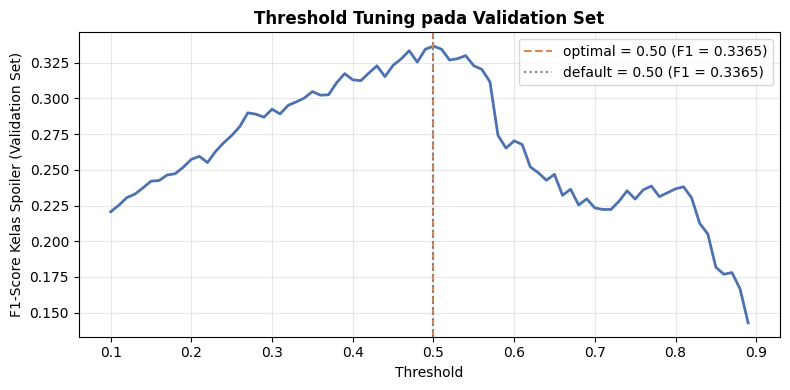

In [ ]:
# ============================================================
# [PAPER] OPSIONAL - threshold tuning IndoBERT
# Karena threshold optimal IndoBERT = 0.50 (sama dengan default),
# cell ini tidak wajib masuk paper. Tetap ditampilkan untuk kelengkapan analisis.
# ============================================================

thresholds    = np.arange(0.1, 0.9, 0.01)
f1_val_scores = []

for thresh in thresholds:
    y_pred = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_val_arr, y_pred, pos_label=1, zero_division=0)
    f1_val_scores.append(f1)

best_idx       = np.argmax(f1_val_scores)
best_threshold = thresholds[best_idx]
best_f1_val    = f1_val_scores[best_idx]

default_idx = np.argmin(np.abs(thresholds - 0.5))
f1_default  = f1_val_scores[default_idx]

print(f"threshold optimal (dari val set) : {best_threshold:.2f}")
print(f"F1 spoiler pada threshold optimal : {best_f1_val:.4f}")
print(f"F1 spoiler pada threshold default : {f1_default:.4f}")

# MODIFIKASI: warna formal hitam-abu, DPI 300
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thresholds, f1_val_scores, color="#1A1A1A", lw=1.8, label="F1-Score Spoiler")
ax.axvline(x=best_threshold, color="#444444", ls="--", lw=1.5,
           label=f"Threshold Optimal = {best_threshold:.2f} (F1 = {best_f1_val:.4f})")
ax.axvline(x=0.5, color="#AAAAAA", ls=":", lw=1.2,
           label=f"Threshold Default = 0.50 (F1 = {f1_default:.4f})")
ax.set_xlabel("Threshold", fontsize=10)
ax.set_ylabel("F1-Score Kelas Spoiler\n(Validation Set)", fontsize=10)
ax.set_title("Threshold Tuning Model IndoBERT pada Validation Set",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("bert_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# sekarang evaluasi di TEST SET menggunakan threshold yang ditemukan di val set
print("menghitung prediksi di test set...")
test_predictions = trainer.predict(test_dataset)
test_logits = test_predictions.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1)[:, 1].numpy()
y_test_arr = np.array(y_test)

# prediksi dengan threshold default dan threshold optimal
y_pred_default = (test_probs >= 0.50).astype(int)
y_pred_optimal = (test_probs >= best_threshold).astype(int)

# AUC tidak bergantung threshold
test_auc = roc_auc_score(y_test_arr, test_probs)

print("EVALUASI DI TEST SET")
print(f"\nAUC-ROC (tidak bergantung threshold): {test_auc:.4f}")

print(f"\nthreshold default (0.50)")
print(classification_report(
  y_test_arr, y_pred_default,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))

print(f"\nthreshold optimal ({best_threshold:.2f})")
print(classification_report(
  y_test_arr, y_pred_optimal,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))

menghitung prediksi di test set...


EVALUASI DI TEST SET

AUC-ROC (tidak bergantung threshold): 0.7554

threshold default (0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9396    0.8843    0.9111      2057
    spoiler (1)     0.2516    0.4061    0.3107       197

       accuracy                         0.8425      2254
      macro avg     0.5956    0.6452    0.6109      2254
   weighted avg     0.8794    0.8425    0.8586      2254


threshold optimal (0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9396    0.8843    0.9111      2057
    spoiler (1)     0.2516    0.4061    0.3107       197

       accuracy                         0.8425      2254
      macro avg     0.5956    0.6452    0.6109      2254
   weighted avg     0.8794    0.8425    0.8586      2254



In [ ]:
# detail threshold analysis IndoBERT
print("DETAIL THRESHOLD ANALYSIS INDOBERT")
print(f"threshold optimal dari val set: {best_threshold:.2f}")
print()

print("trade-off precision vs recall di berbagai threshold")
print(f"{'threshold':>10} {'precision':>10} {'recall':>10} {'f1':>10} {'TP':>6} {'FP':>6} {'FN':>6}")

for t in [0.30, 0.40, 0.50, 0.55, 0.60, best_threshold, 0.70, 0.75, 0.80]:
  yp = (test_probs >= t).astype(int)
  prec = precision_score(y_test_arr, yp, pos_label=1, zero_division=0)
  rec = recall_score(y_test_arr, yp, pos_label=1, zero_division=0)
  f1 = f1_score(y_test_arr, yp, pos_label=1, zero_division=0)
  cm = confusion_matrix(y_test_arr, yp)
  tp, fp, fn = cm[1,1], cm[0,1], cm[1,0]
  marker = " <-- optimal" if abs(t - best_threshold) < 0.001 else ""
  print(f"{t:>10.2f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {tp:>6} {fp:>6} {fn:>6}{marker}")

print()

# ringkasan final
print("RINGKASAN METRIK FINAL INDOBERT")
for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
  print(f"\nthreshold {label}")
  print(f"AUC-ROC         : {test_auc:.4f}")
  print(f"F1 makro        : {f1_score(y_test_arr, y_pred, average='macro', zero_division=0):.4f}")
  print(f"F1 spoiler      : {f1_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Presisi spoiler : {precision_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Recall spoiler  : {recall_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"F1 non-spoiler  : {f1_score(y_test_arr, y_pred, pos_label=0, zero_division=0):.4f}")
  cm = confusion_matrix(y_test_arr, y_pred)
  print(f"TP={cm[1,1]} FP={cm[0,1]} FN={cm[1,0]} TN={cm[0,0]}")

# cek distribusi probabilitas
print("\nDISTRIBUSI PROBABILITAS TEST SET")
print(f"min: {test_probs.min():.4f}")
print(f"max: {test_probs.max():.4f}")
print(f"mean: {test_probs.mean():.4f}")
print(f"median: {np.median(test_probs):.4f}")
print(f"\nproporsisampel dengan prob > 0.5 : {(test_probs > 0.5).mean()*100:.1f}%")
print(f"proporsi sampel dengan prob > threshold optimal: {(test_probs > best_threshold).mean()*100:.1f}%")

DETAIL THRESHOLD ANALYSIS INDOBERT
threshold optimal dari val set: 0.50

trade-off precision vs recall di berbagai threshold
 threshold  precision     recall         f1     TP     FP     FN
      0.30     0.1909     0.6142     0.2912    121    513     76
      0.40     0.2190     0.4924     0.3031     97    346    100
      0.50     0.2516     0.4061     0.3107     80    238    117 <-- optimal
      0.55     0.2605     0.3452     0.2969     68    193    129
      0.60     0.2844     0.3147     0.2988     62    156    135
      0.50     0.2516     0.4061     0.3107     80    238    117 <-- optimal
      0.70     0.3406     0.2386     0.2806     47     91    150
      0.75     0.3486     0.1929     0.2484     38     71    159
      0.80     0.3951     0.1624     0.2302     32     49    165

RINGKASAN METRIK FINAL INDOBERT

threshold default (0.50)
AUC-ROC         : 0.7554
F1 makro        : 0.6109
F1 spoiler      : 0.3107
Presisi spoiler : 0.2516
Recall spoiler  : 0.4061
F1 non-spoiler  :

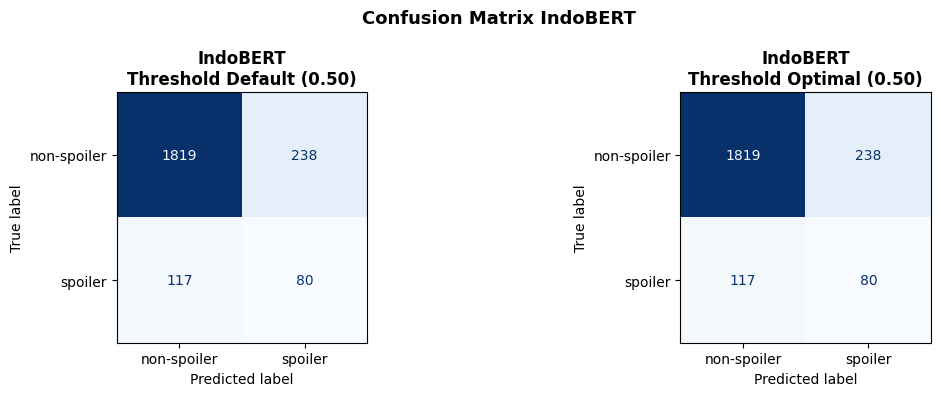

In [ ]:
# ============================================================
# [PAPER] OUTPUT INI MASUK PAPER
# Gambar: Confusion Matrix Model IndoBERT
# Caption: Gambar X. Confusion Matrix Model IndoBERT pada Data Uji (Threshold 0.50)
# Sumber: (Hasil Penelitian, 2026)
# Catatan: karena threshold optimal = default (0.50), kedua panel identik.
#          Untuk paper, cukup tampilkan satu panel saja (lihat cell berikutnya).
# ============================================================

# MODIFIKASI: cmap Greys untuk konsistensi dengan notebook ML dan BiLSTM
# MODIFIKASI: label sumbu formal
# MODIFIKASI: DPI 300

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

for ax, (title, y_pred) in zip(axes, [
    ("Threshold Default (0.50)", y_pred_default),
    (f"Threshold Optimal ({best_threshold:.2f})", y_pred_optimal)
]):
    cm = confusion_matrix(y_test_arr, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Spoiler", "Spoiler"]
    )
    # MODIFIKASI: Greys menggantikan Blues
    disp.plot(ax=ax, colorbar=False, cmap="Greys")
    ax.set_title(f"IndoBERT\n{title}", fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Label Prediksi", fontsize=9)
    ax.set_ylabel("Label Aktual", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle("Confusion Matrix Model IndoBERT",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ── versi single panel untuk paper (karena threshold optimal = default) ──
# ============================================================
# [PAPER] GUNAKAN INI JIKA HANYA INGIN SATU PANEL DI PAPER
# Caption: Gambar X. Confusion Matrix Model IndoBERT pada Data Uji
# ============================================================
fig2, ax2 = plt.subplots(figsize=(4, 3.5))
cm = confusion_matrix(y_test_arr, y_pred_default)
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Spoiler", "Spoiler"]
)
disp2.plot(ax=ax2, colorbar=False, cmap="Greys")
ax2.set_title("Confusion Matrix Model IndoBERT\n(Threshold 0.50)",
              fontsize=10, fontweight="bold")
ax2.set_xlabel("Label Prediksi", fontsize=9)
ax2.set_ylabel("Label Aktual", fontsize=9)
plt.tight_layout()
plt.savefig("bert_confusion_matrix_single.png", dpi=300, bbox_inches="tight")
plt.show()


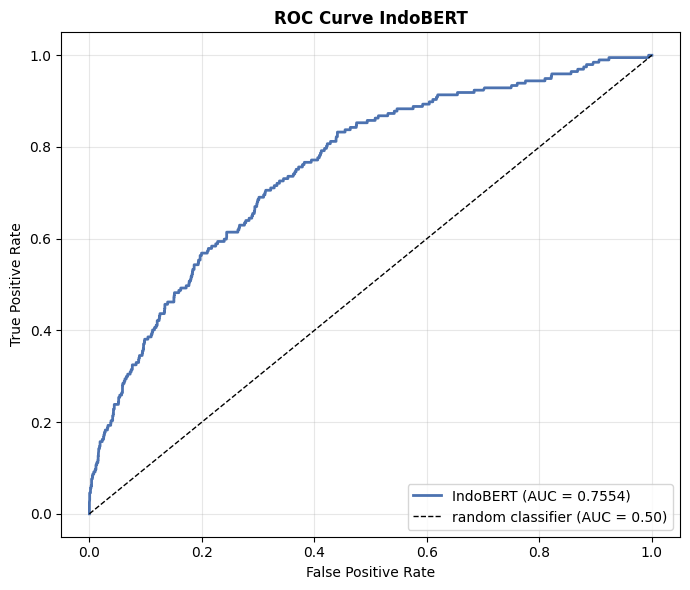

In [ ]:
# ============================================================
# [PAPER] OUTPUT INI OPSIONAL (bisa digabung dengan ROC lain)
# Gambar: Kurva ROC Model IndoBERT
# Jika dimasukkan paper, beri caption:
# Gambar X. Kurva ROC Model IndoBERT pada Data Uji
# Sumber: (Hasil Penelitian, 2026)
# ============================================================

# MODIFIKASI: warna hitam formal, label sumbu formal, DPI 300

fpr, tpr, _ = roc_curve(y_test_arr, test_probs)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color="#1A1A1A", lw=1.8, label=f"IndoBERT (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="lightgray", lw=1, ls=":", label="Random Classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate (FPR)", fontsize=10)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=10)
ax.set_title("Kurva ROC Model IndoBERT", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="lower right", framealpha=0.85)
ax.grid(alpha=0.2, linewidth=0.6)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("bert_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. visualisasi training history

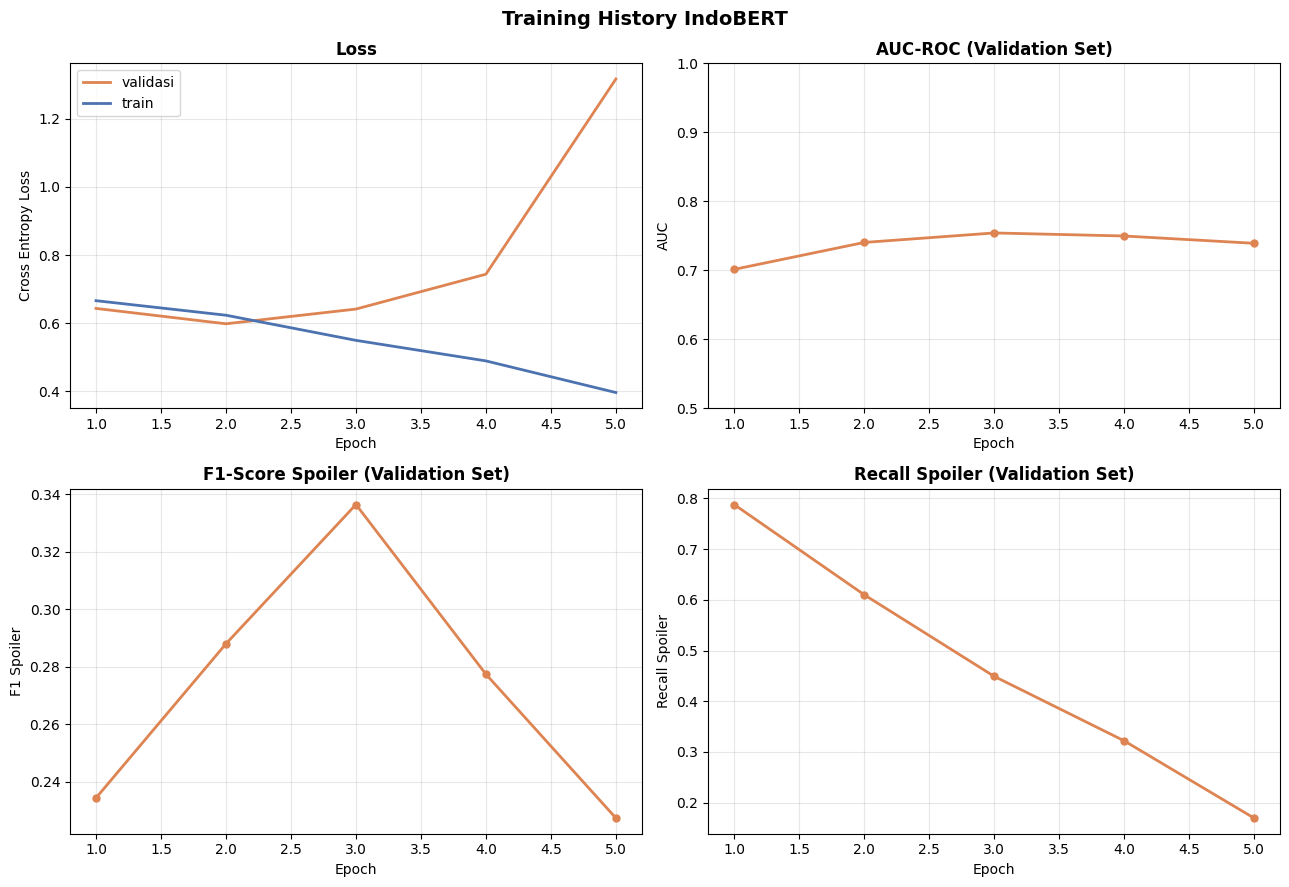

epoch terbaik (AUC tertinggi): epoch 3 (AUC = 0.7541)
training berhenti di epoch: 5


In [ ]:
# ============================================================
# [PAPER] OUTPUT INI MASUK PAPER
# Gambar: Kurva Training Model IndoBERT
# Caption: Gambar X. Kurva Training Model IndoBERT per Epoch
# Sumber: (Hasil Penelitian, 2026)
# Keterangan: epoch terbaik ditandai dengan garis vertikal
# ============================================================

# MODIFIKASI: warna train = hitam (#1A1A1A), validasi = abu-abu (#777777)
# MODIFIKASI: tambah garis vertikal penanda epoch terbaik
# MODIFIKASI: DPI 300 untuk ketajaman di paper dua kolom
# MODIFIKASI: label sumbu formal, judul tanpa em dash, sebut "Model" untuk DL
# MODIFIKASI: sumbu Y AUC dimulai dari 0.5 agar skala lebih informatif

log_history = trainer.state.log_history
train_logs  = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs   = [l for l in log_history if "eval_loss" in l]

if not eval_logs:
    print("log evaluasi tidak tersedia, skip plotting")
else:
    epochs       = [l["epoch"] for l in eval_logs]
    eval_loss    = [l["eval_loss"] for l in eval_logs]
    eval_auc     = [l.get("eval_auc_roc", 0) for l in eval_logs]
    eval_f1      = [l.get("eval_f1_spoiler", 0) for l in eval_logs]
    eval_rec     = [l.get("eval_recall_spoiler", 0) for l in eval_logs]
    train_loss_per_epoch = [l["loss"] for l in train_logs if "loss" in l][:len(epochs)]

    # epoch terbaik berdasarkan AUC tertinggi
    best_epoch_idx = int(np.argmax(eval_auc))
    best_epoch_val = epochs[best_epoch_idx]

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    subplot_configs = [
        ("Loss",              epochs, eval_loss, train_loss_per_epoch, "Cross-Entropy Loss", False),
        ("AUC-ROC",           epochs, eval_auc,  None,                 "AUC-ROC",            True),
        ("F1-Score Spoiler",  epochs, eval_f1,   None,                 "F1-Score Spoiler",   False),
        ("Recall Spoiler",    epochs, eval_rec,  None,                 "Recall Spoiler",     False),
    ]

    for ax, (title, ep, val_data, train_data, ylabel, lim) in zip(axes.flatten(), subplot_configs):
        # MODIFIKASI: validasi abu, train hitam
        ax.plot(ep, val_data, color="#777777", lw=1.8, ls="--", marker="o",
                markersize=4, label="Validasi")
        if train_data:
            ax.plot(ep[:len(train_data)], train_data, color="#1A1A1A", lw=1.8, label="Train")
        # garis epoch terbaik
        ax.axvline(x=best_epoch_val, color="#AAAAAA", ls=":", lw=1.2,
                   label=f"Epoch Terbaik = {best_epoch_val:.0f}")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        if lim:
            ax.set_ylim(0.5, 1.0)
        ax.legend(fontsize=7.5, framealpha=0.85)
        ax.grid(alpha=0.18, linewidth=0.6)
        ax.spines[["top","right"]].set_visible(False)

    plt.suptitle("Kurva Training Model IndoBERT per Epoch",
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("bert_training_history.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"epoch terbaik (AUC tertinggi): epoch {best_epoch_val:.0f} (AUC = {max(eval_auc):.4f})")
    print(f"training berhenti di epoch: {epochs[-1]:.0f}")


In [ ]:
# ringkasan metrik final untuk memudahkan perbandingan dengan model lain
print("RINGKASAN METRIK FINAL INDOBERT")
for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
    print(f"\nthreshold {label}")
    print(f"AUC-ROC         : {test_auc:.4f}")
    print(f"F1 makro        : {f1_score(y_test_arr, y_pred, average='macro'):.4f}")
    print(f"F1 spoiler      : {f1_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"Presisi spoiler : {precision_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"Recall spoiler  : {recall_score(y_test_arr, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"F1 non-spoiler  : {f1_score(y_test_arr, y_pred, pos_label=0, zero_division=0):.4f}")

RINGKASAN METRIK FINAL INDOBERT

threshold default (0.50)
AUC-ROC         : 0.7554
F1 makro        : 0.6109
F1 spoiler      : 0.3107
Presisi spoiler : 0.2516
Recall spoiler  : 0.4061
F1 non-spoiler  : 0.9111

threshold optimal (0.50)
AUC-ROC         : 0.7554
F1 makro        : 0.6109
F1 spoiler      : 0.3107
Presisi spoiler : 0.2516
Recall spoiler  : 0.4061
F1 non-spoiler  : 0.9111


In [ ]:
print("CEK BOBOT YANG DIPAKAI")
print(f"AUC terbaik (dari log): {trainer.state.best_metric:.4f}")
print(f"path model terbaik: {trainer.state.best_model_checkpoint}")
print()

print("LOG PER EPOCH")
for log in trainer.state.log_history:
  if "eval_auc_roc" in log:
    print(f"epoch {log['epoch']:.0f} | eval_loss: {log['eval_loss']:.4f} | eval_auc: {log['eval_auc_roc']:.4f} | eval_f1: {log.get('eval_f1_spoiler', 0):.4f}")

CEK BOBOT YANG DIPAKAI
AUC terbaik (dari log): 0.7541
path model terbaik: /content/drive/MyDrive/NLP_Kelompok3/indobert_output/checkpoint-1437

LOG PER EPOCH
epoch 1 | eval_loss: 0.6433 | eval_auc: 0.7013 | eval_f1: 0.2343
epoch 2 | eval_loss: 0.5982 | eval_auc: 0.7403 | eval_f1: 0.2880
epoch 3 | eval_loss: 0.6415 | eval_auc: 0.7541 | eval_f1: 0.3365
epoch 4 | eval_loss: 0.7438 | eval_auc: 0.7497 | eval_f1: 0.2774
epoch 5 | eval_loss: 1.3169 | eval_auc: 0.7391 | eval_f1: 0.2273


## 11. ringkasan dan catatan

keunggulan indobert atas bilstm:
- konteks bidirectional sesungguhnya melalui self-attention (bukan rnn sekuensial)
- representasi kontekstual: kata yang sama mendapat vektor berbeda tergantung konteks kalimat
- konvergensi cepat karena pengetahuan bahasa sudah tertanam dari pretrain

keterbatasan:
- batas maksimum 512 token (dipakai 256), review panjang terpotong
- butuh gpu dan waktu lebih lama dibanding algoritma ml tradisional

In [ ]:
# ============================================================
# [paper] output ini masuk paper -> gambar 7
# caption: gambar 7. kurva roc semua pendekatan yang diuji pada data uji
# sumber: (hasil penelitian, 2026)
# keterangan: semakin kurva mendekati pojok kiri atas, semakin baik kemampuan diskriminasi
# ============================================================

# cell ini menggabungkan roc curve dari tiga algoritma ml (diload dari pickle)
# dan dua model deep learning (bilstm dan indobert) dalam satu gambar
# jalankan setelah notebook bilstm dan ml sudah selesai dijalankan
# dan file roc_scores_ml.pkl serta roc_scores_bilstm.pkl sudah tersedia

import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# -- load skor roc dari notebook ml --
# pastikan file roc_scores_ml.pkl sudah dihasilkan dari notebook ml
try:
    with open(os.path.join(DRIVE_BASE, "roc_scores_ml.pkl"), "rb") as f:
        roc_ml = pickle.load(f)
    y_test_ref = np.array(roc_ml["y_test"])
    print("roc scores ml berhasil diload")
except FileNotFoundError:
    print("roc_scores_ml.pkl tidak ditemukan, jalankan notebook ml dulu")
    roc_ml = None

# -- load skor roc dari notebook bilstm --
try:
    with open(os.path.join(DRIVE_BASE, "roc_scores_bilstm.pkl"), "rb") as f:
        roc_bilstm = pickle.load(f)
    print("roc scores bilstm berhasil diload")
except FileNotFoundError:
    print("roc_scores_bilstm.pkl tidak ditemukan, jalankan notebook bilstm dulu")
    roc_bilstm = None

# -- skor indobert sudah tersedia di session ini sebagai test_probs --
# y_test_arr dan test_probs sudah didefinisikan di cell evaluasi final

if roc_ml is not None and roc_bilstm is not None:
    # konfigurasi tiap kurva: (label, skor, warna, linestyle)
    # urutan: dari yang terbaik ke terendah berdasarkan auc
    curve_configs = [
        ("IndoBERT",       test_probs,                           "#1A1A1A", "-",   2.0),
        ("SVM (Linear)",   np.array(roc_ml["SVM (Linear)"]),    "#333333", "--",  1.8),
        ("Random Forest",  np.array(roc_ml["Random Forest"]),   "#555555", "-.",  1.6),
        ("BiLSTM",         np.array(roc_bilstm["y_prob"]),      "#888888", ":",   1.6),
        ("XGBoost",        np.array(roc_ml["XGBoost"]),         "#AAAAAA", "--",  1.4),
    ]

    fig, ax = plt.subplots(figsize=(6, 5.5))

    for label, scores, color, ls, lw in curve_configs:
        # gunakan y_test_arr (indobert) sebagai referensi, semua split data sama
        fpr, tpr, _ = roc_curve(y_test_arr, scores)
        auc_val = roc_auc_score(y_test_arr, scores)
        ax.plot(fpr, tpr, label=f"{label} (AUC = {auc_val:.4f})",
                color=color, ls=ls, lw=lw)

    # garis baseline random classifier
    ax.plot([0,1],[0,1], color="#DDDDDD", lw=1, ls=":", label="Random Classifier (AUC = 0.50)")

    ax.set_xlabel("False Positive Rate (FPR)", fontsize=10)
    ax.set_ylabel("True Positive Rate (TPR)", fontsize=10)
    ax.set_title("Kurva ROC Semua Pendekatan pada Data Uji",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
    ax.grid(alpha=0.18, linewidth=0.6)
    ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_BASE, "roc_gabungan_semua_model.png"), dpi=300, bbox_inches="tight")
    plt.show()
    print("gambar disimpan ke drive")
else:
    print("tidak bisa membuat roc gabungan karena skor ml atau bilstm belum tersedia")